# Pipeline de Dados — Sistema de Recomendação de Cursos - Teste
**Projeto Aplicado III — Universidade Presbiteriana Mackenzie**

Este notebook prepara os dados do Coursera para modelagem por aprendizado de máquina.

---
## 0. Configuração do Ambiente

In [1]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


# Bibliotecas de visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Nuvem de palavras
from wordcloud import WordCloud, STOPWORDS

# Utilitários de texto
import re
from collections import Counter

# Configurações gerais
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 100)



In [2]:
# Funções de análise de reviews
def reviews_histogram(reviews_in, maxcount= 100000) :
    
    # Contagem de reviews por usuário
    counts = reviews_in['reviewers'].value_counts()
    
    # Filtra apenas quem tem ≤ maxcount reviews
    filtered = counts[counts <= maxcount]
    
    # Histograma
    plt.figure(figsize=(4, 2))
    plt.hist(filtered, bins=range(0, int(maxcount *1.1), 5), color='teal', edgecolor='black')
    plt.yscale('log')  # ← Escala logarítmica no eixo y
    plt.title('Usuários com até '+str(maxcount)+' reviews')
    plt.xlabel('Número de reviews')
    plt.ylabel('Quantidade de usuários')
    plt.xticks(range(0, int(maxcount *1.1), 10))
    plt.grid(True, alpha=0.3)
    plt.show()

def reviews_quantis(reviews_in):
    # Contagem de reviews por usuário
    counts = reviews_in['reviewers'].value_counts()
    
    # Quintis (0%, 25%, 50%, 75%, 100%) + alguns extras úteis
    quintis = counts.quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99,0.995,0.999,0.9995, 1.0])
    
    print("Quantis do número de reviews por usuário:")
    print(quintis.round(0).astype(int)) 

def reviews_top(reviews_in):
    top10 = reviews_in['reviewers'].value_counts().head(5)

    plt.figure(figsize=(4, 2))
    plt.barh(top10.index, top10.values, color='skyblue')
    plt.xlabel('Quantidade de avaliações')
    plt.title('Top 5 Reviewers')
    plt.gca().invert_yaxis()  # maior no topo
    for i, v in enumerate(top10.values):
        plt.text(v + 5, i, str(v), va='center')
    plt.show()

---
## 1. Carregamento dos Dados

In [3]:
# Carrega o catálogo de cursos
courses_df = pd.read_csv('../data/Coursera_courses.csv')

# Carrega as avaliações com tipos otimizados para economizar memória
reviews_df = pd.read_csv(
    '../data/Coursera_reviews.csv',
    dtype={'rating': 'int8', 'course_id': 'category'}
)

print('=== Catálogo de cursos ===')
print(f'Linhas: {courses_df.shape[0]:,} | Colunas: {courses_df.shape[1]}')
print()
print('=== Avaliações ===')
print(f'Linhas: {reviews_df.shape[0]:,} | Colunas: {reviews_df.shape[1]}')
display(courses_df.head(5))
display(reviews_df.head(5))

=== Catálogo de cursos ===
Linhas: 623 | Colunas: 4

=== Avaliações ===
Linhas: 1,454,711 | Colunas: 5


,name,institution,course_url,course_id
0,Machine Learning,Stanford University,https://www.coursera.org/learn/machine-learning,machine-learning
1,Indigenous Canada,University of Alberta,https://www.coursera.org/learn/indigenous-canada,indigenous-canada
2,The Science of Well-Being,Yale University,https://www.coursera.org/learn/the-science-of-well-being,the-science-of-well-being
3,Technical Support Fundamentals,Google,https://www.coursera.org/learn/technical-support-fundamentals,technical-support-fundamentals
4,Become a CBRS Certified Professional Installer by Google,Google - Spectrum Sharing,https://www.coursera.org/learn/google-cbrs-cpi-training,google-cbrs-cpi-training


,reviews,reviewers,date_reviews,rating,course_id
0,"Pretty dry, but I was able to pass with just two complete watches so I'm happy about that. As u...",By Robert S,"Feb 12, 2020",4,google-cbrs-cpi-training
1,would be a better experience if the video and screen shots would sho on the side of the text tha...,By Gabriel E R,"Sep 28, 2020",4,google-cbrs-cpi-training
2,Information was perfect! The program itself was a little annoying. I had to wait 30 to 45 minute...,By Jacob D,"Apr 08, 2020",4,google-cbrs-cpi-training
3,A few grammatical mistakes on test made me do a double take but all in all not bad.,By Dale B,"Feb 24, 2020",4,google-cbrs-cpi-training
4,Excellent course and the training provided was very detailed and easy to follow.,By Sean G,"Jun 18, 2020",4,google-cbrs-cpi-training


---
## 2. Sanitização

In [4]:
# Arruma datas nas avaliações
reviews_san_df= reviews_df.copy()
reviews_san_df['date_reviews'] = reviews_san_df['date_reviews'] = pd.to_datetime(
    reviews_san_df['date_reviews']
        .astype(str)
        .str.replace('\xa0', ' ')   # remove espaço não-quebrável
        .str.strip(),
    format='%b %d, %Y',
    errors='coerce'
)

# Remove "By " do início de strings na coluna (ex: 'reviewers')
reviews_san_df['reviewers'] = reviews_san_df['reviewers'].str.replace(r'^By\s+', '', regex=True)
print(reviews_san_df.info())
display(reviews_san_df.head(5))



# Salva datasets como parquet
reviews_san_df.to_parquet('../test_data/reviews.parquet')
courses_df.to_parquet('../test_data/courses.parquet')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1454711 entries, 0 to 1454710
Data columns (total 5 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   reviews       1454558 non-null  object        
 1   reviewers     1454711 non-null  object        
 2   date_reviews  1454711 non-null  datetime64[ns]
 3   rating        1454711 non-null  int8          
 4   course_id     1454711 non-null  category      
dtypes: category(1), datetime64[ns](1), int8(1), object(2)
memory usage: 37.5+ MB
None


,reviews,reviewers,date_reviews,rating,course_id
0,"Pretty dry, but I was able to pass with just two complete watches so I'm happy about that. As u...",Robert S,2020-02-12,4,google-cbrs-cpi-training
1,would be a better experience if the video and screen shots would sho on the side of the text tha...,Gabriel E R,2020-09-28,4,google-cbrs-cpi-training
2,Information was perfect! The program itself was a little annoying. I had to wait 30 to 45 minute...,Jacob D,2020-04-08,4,google-cbrs-cpi-training
3,A few grammatical mistakes on test made me do a double take but all in all not bad.,Dale B,2020-02-24,4,google-cbrs-cpi-training
4,Excellent course and the training provided was very detailed and easy to follow.,Sean G,2020-06-18,4,google-cbrs-cpi-training


---
## 3. Limpeza de duplicatas nas avaliações, usuários inválidos

In [5]:
#Remove usuário 'Deleted A'

reviews_dedup_df = reviews_san_df[~reviews_san_df['reviewers'].str.contains('deleted', case=False, na=False)].copy()

#Remove pares duplicados de reviewers/course_id, deixando último.

reviews_dedup_df = reviews_dedup_df.sort_values('date_reviews')  # Ordena por 'C' (crescente; use ascending=False se decrescente)
reviews_dedup_df = reviews_dedup_df.drop_duplicates(subset=['reviewers', 'course_id'], keep='last')  # Mantém o último

print(len(reviews_san_df))
display(reviews_san_df.head(3))
print(len(reviews_dedup_df))
display(reviews_dedup_df.head(3))
reviews_dedup_df.to_parquet('../test_data/reviews_DEDUP.parquet')
print(f"Deduplicação")
print(f"Reviews antes: {len(reviews_san_df)} | Após: {len(reviews_dedup_df)}")


1454711


,reviews,reviewers,date_reviews,rating,course_id
0,"Pretty dry, but I was able to pass with just two complete watches so I'm happy about that. As u...",Robert S,2020-02-12,4,google-cbrs-cpi-training
1,would be a better experience if the video and screen shots would sho on the side of the text tha...,Gabriel E R,2020-09-28,4,google-cbrs-cpi-training
2,Information was perfect! The program itself was a little annoying. I had to wait 30 to 45 minute...,Jacob D,2020-04-08,4,google-cbrs-cpi-training


505733


,reviews,reviewers,date_reviews,rating,course_id
1029873,"Doing this course 'Budgeting and Scheduling projects' gives learners, a practical approach to Pr...",Vijayakumar M N,2015-08-07,5,schedule-projects
807761,Good course for beginners!,Paulo E L d S,2015-08-07,5,learn-chinese
806596,it's easy to understand. really good course.,Giuliano P,2015-08-07,5,learn-chinese


Deduplicação
Reviews antes: 1454711 | Após: 505733


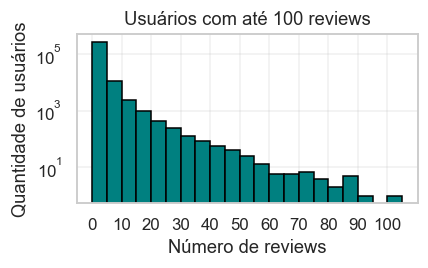

Quantis do número de reviews por usuário:
0.0000      1
0.2500      1
0.5000      1
0.7500      2
0.9000      3
0.9500      5
0.9900     12
0.9950     17
0.9990     33
0.9995     41
1.0000    123
Name: count, dtype: int64


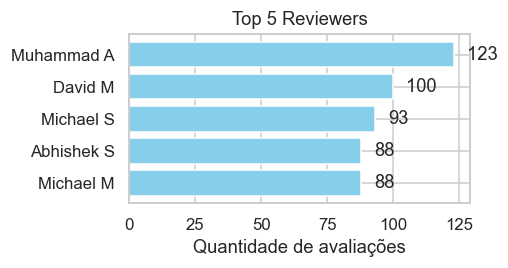

In [6]:
reviews_histogram(reviews_dedup_df, maxcount= 100)
reviews_quantis(reviews_dedup_df)
reviews_top(reviews_dedup_df)

#### A remoção usuários apagados e de duplicidade (reviewers/course_id) reduziu a base de 1.45mm para 505k registros. Ainda temos contudo alguns 'Zé da Silva', que devem agregar vários usuários.
---

In [7]:
# Conta reviews por usuário

reviews_por_usuario = reviews_dedup_df['reviewers'].value_counts()

# Calcula quantil 99.9% (ex: remove acima dele)
quantil = reviews_por_usuario.quantile(0.999)

# Remove usuários acima do quantil
usuarios_remover = reviews_por_usuario[reviews_por_usuario > quantil].index
reviews_dedup_qtl_df = reviews_dedup_df[~reviews_dedup_df['reviewers'].isin(usuarios_remover)]

print(f"Quantil 99.5%: {quantil}")
print(f"Reviews antes: {len(reviews_dedup_df)} | Após: {len(reviews_dedup_qtl_df)}")
reviews_dedup_qtl_df.to_parquet('../test_data/reviews_DEDUP_QTL.parquet')


Quantil 99.5%: 33.0
Reviews antes: 505733 | Após: 493011


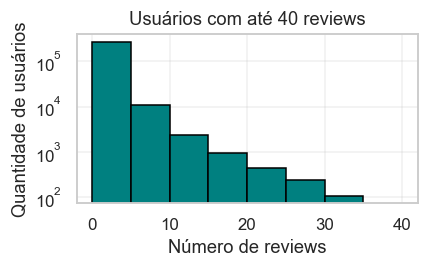

Quantis do número de reviews por usuário:
0.0000     1
0.2500     1
0.5000     1
0.7500     2
0.9000     3
0.9500     5
0.9900    11
0.9950    16
0.9990    25
0.9995    28
1.0000    33
Name: count, dtype: int64


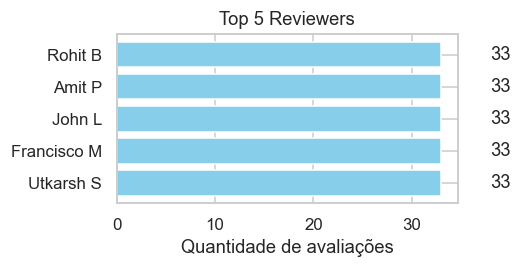

In [8]:
reviews_histogram(reviews_dedup_qtl_df, maxcount= 40)
reviews_quantis(reviews_dedup_qtl_df)
reviews_top(reviews_dedup_qtl_df)

#### Com a filtragem até o quantil 99.9% a partir da base já deduplicada os nomes nas posições de destaque já soam únicos. O critério é arbitrário, descarta  masi 12k reviews. Deve ser considerado com cuidado.

#### O agrupamento de diversos perfis sob o mesmo nome cria problemas no agupamento, criando *usuários artificiais* de abrangência exagerada. 
---

---
## 4. Merge com catálogo de cursos

In [9]:
# --- Dartaset : merge dedup/qtl + cursos ---
reviews_df = reviews_dedup_qtl_df.merge(courses_df, on='course_id', how='left')

# Verifica órfãos (reviews sem curso correspondente)
orfaos = reviews_df[reviews_df['name'].isna()]
print(f"Merge concluído: {len(reviews_df):,} reviews")
print(f"Órfãos (reviews sem curso): {len(orfaos):,}")

# Remove órfãos se existirem
if len(orfaos) > 0:
    print(f"  course_ids órfãos: {orfaos['course_id'].unique()}")
    reviews_df = reviews_df.dropna(subset=['name'])
    print(f"  Após remoção: {len(reviews_df):,} reviews")

reviews_df.to_parquet('../test_data/reviews_merged.parquet')
display(reviews_df.head(3))
print(f"\nUsuários únicos: {reviews_df['reviewers'].nunique():,}")
print(f"Cursos únicos:   {reviews_df['course_id'].nunique():,}")


Merge concluído: 493,011 reviews
Órfãos (reviews sem curso): 0


,reviews,reviewers,date_reviews,rating,course_id,name,institution,course_url
0,"Doing this course 'Budgeting and Scheduling projects' gives learners, a practical approach to Pr...",Vijayakumar M N,2015-08-07,5,schedule-projects,Budgeting and Scheduling Projects,"University of California, Irvine",https://www.coursera.org/learn/schedule-projects
1,Good course for beginners!,Paulo E L d S,2015-08-07,5,learn-chinese,Chinese for Beginners,Peking University,https://www.coursera.org/learn/learn-chinese
2,it's easy to understand. really good course.,Giuliano P,2015-08-07,5,learn-chinese,Chinese for Beginners,Peking University,https://www.coursera.org/learn/learn-chinese



Usuários únicos: 287,391
Cursos únicos:   604


## 4a. Knn user based está estourando RAM => 150+GB => Crash

Remover aleatoriamente parte da base para tespe preliminar. Ver critérios depois.

In [10]:
user_counts = reviews_df.groupby('reviewers').size().reset_index(name='count')
print(len(user_counts))
print(user_counts.sample(10))

# Ordena por reviewer e pegag X%.
prcent_keep = 50
user_counts_sorted = user_counts.sort_values('reviewers', ascending=False)
num_keep = int(len(user_counts_sorted) *(prcent_keep/100))
users_keep = user_counts_sorted.iloc[:num_keep]

print("=" * 65)
print(len(users_keep))
print(users_keep.sample(10))

reviews_df_culled = reviews_df[
    reviews_df['reviewers'].isin(users_keep['reviewers'])
]
print("="* 65)
print("="* 65)


print("Reviews antes: ",len(reviews_df))
print("Reviews depois: ",len(reviews_df_culled))

    

287391
          reviewers  count
276751     shun y p      1
187145     Pratik U      4
83711       Glory E      1
101859  Jairo A A F      1
154900    Mertcan Ö      1
54830   Danny A A B      1
107391    Jiayang T      5
188668      Purva V      1
3559       APARNA R      2
106223  Jessica E H      1
143695
            reviewers  count
267916     jyothish a      1
254761        Yeset C      1
146928    Maria N F M      1
155359  Michael L S I      1
182177  Paula F F d C      1
160608     Mosarrat M      1
270801      matthew C      1
245475    Victor O A       1
193737   Ramacandra W      1
157306   Minnette W S      1
Reviews antes:  493011
Reviews depois:  241865


---
## 5. Matriz pivô, formato esparso e normalização

Construímos a matriz usuário × curso com ratings. Convertemos para CSR (Compressed Sparse Row) para eficiência de memória. A versão normalizada (mean-centering) corrige o viés positivo dos ratings.

In [11]:
from scipy import sparse

# Matriz pivô: usuários nas linhas, cursos nas colunas, ratings nos valores
pivot_df = reviews_df_culled.pivot_table(
    index='reviewers',
    columns='course_id',
    values='rating',
    aggfunc='last'  # último rating caso reste duplicata residual
)

print(f"Matriz pivô: {pivot_df.shape[0]:,} usuários × {pivot_df.shape[1]:,} cursos")

# Densidade real
total_cells = pivot_df.shape[0] * pivot_df.shape[1]
filled_cells = pivot_df.notna().sum().sum()
density = filled_cells / total_cells
print(f"Células preenchidas: {filled_cells:,} / {total_cells:,}")
print(f"Densidade: {density:.4f} ({density*100:.2f}%)")
print(f"Esparsidade: {1 - density:.4f} ({(1 - density)*100:.2f}%)")

# Converte para CSR (NaN → 0 no formato esparso)
pivot_filled = pivot_df.fillna(0)
matrix_csr = sparse.csr_matrix(pivot_filled.values)
print(f"\nCSR: {matrix_csr.shape}, nnz={matrix_csr.nnz:,}, dtype={matrix_csr.dtype}")

# Versão normalizada (mean-centering por usuário)
user_means = pivot_df.mean(axis=1)  # média por usuário (ignora NaN)
pivot_norm_df = pivot_df.sub(user_means, axis=0)
pivot_norm_filled = pivot_norm_df.fillna(0)
matrix_norm_csr = sparse.csr_matrix(pivot_norm_filled.values)

print(f"\nMean-centering aplicado:")
print(f"  Média das médias por usuário: {user_means.mean():.2f}")
print(f"  Rating médio normalizado: {pivot_norm_df.stack().mean():.4f} (esperado ≈ 0)")

# Salva artefatos: parquet para DataFrames, npz para matrizes esparsas
pivot_df.to_parquet('../test_data/matrix_pivot.parquet')
sparse.save_npz('../test_data/matrix_csr.npz', matrix_csr)
sparse.save_npz('../test_data/matrix_norm_csr.npz', matrix_norm_csr)
user_means.to_frame('mean_rating').to_parquet('../test_data/matrix_user_means.parquet')

print("\nArtefatos salvos: matrix_pivot.parquet, matrix_csr.npz, matrix_norm_csr.npz, matrix_user_means.parquet")


Matriz pivô: 143,695 usuários × 604 cursos
Células preenchidas: 241,865 / 86,791,780
Densidade: 0.0028 (0.28%)
Esparsidade: 0.9972 (99.72%)

CSR: (143695, 604), nnz=241,865, dtype=float64

Mean-centering aplicado:
  Média das médias por usuário: 4.71
  Rating médio normalizado: -0.0000 (esperado ≈ 0)

Artefatos salvos: matrix_pivot.parquet, matrix_csr.npz, matrix_norm_csr.npz, matrix_user_means.parquet


---
## 6. Divisão temporal treino

Split conforme AED: treino = reviews antes de 2020, teste = 2020 em diante. O pico pandêmico simula cenário real de crescimento de novos usuários.

In [12]:
SPLIT_DATE = pd.Timestamp('2020-01-01')

train_df = reviews_df_culled[reviews_df_culled['date_reviews'] < SPLIT_DATE].copy()
test_df  = reviews_df_culled[reviews_df_culled['date_reviews'] >= SPLIT_DATE].copy()

print(f"Split temporal em {SPLIT_DATE.date()}:")
print(f"  Treino: {len(train_df):,} reviews ({len(train_df)/len(reviews_df_culled)*100:.1f}%)")
print(f"  Teste:  {len(test_df):,} reviews ({len(test_df)/len(reviews_df_culled)*100:.1f}%)")

# Verifica órfãos: usuários/cursos presentes só no teste
train_users  = set(train_df['reviewers'].unique())
test_users   = set(test_df['reviewers'].unique())
train_courses = set(train_df['course_id'].unique())
test_courses  = set(test_df['course_id'].unique())

orphan_users   = test_users - train_users
orphan_courses = test_courses - train_courses

print(f"\nÓrfãos (presentes só no teste):")
print(f"  Usuários: {len(orphan_users):,} (cold start potencial)")
print(f"  Cursos:   {len(orphan_courses):,}")

train_df.to_parquet('../test_data/train_reviews.parquet')
test_df.to_parquet('../test_data/test_reviews.parquet')


Split temporal em 2020-01-01:
  Treino: 113,573 reviews (47.0%)
  Teste:  128,292 reviews (53.0%)

Órfãos (presentes só no teste):
  Usuários: 72,162 (cold start potencial)
  Cursos:   76


In [13]:
# Matrizes pivô separadas para treino e teste

# Treino
train_pivot = train_df.pivot_table(
    index='reviewers', columns='course_id', values='rating', aggfunc='last'
)
train_means = train_pivot.mean(axis=1)
train_norm = train_pivot.sub(train_means, axis=0).fillna(0)
train_csr = sparse.csr_matrix(train_pivot.fillna(0).values)
train_norm_csr = sparse.csr_matrix(train_norm.values)

# Teste
test_pivot = test_df.pivot_table(
    index='reviewers', columns='course_id', values='rating', aggfunc='last'
)

print(f"Matriz treino: {train_pivot.shape[0]:,} × {train_pivot.shape[1]:,}")
print(f"Matriz teste:  {test_pivot.shape[0]:,} × {test_pivot.shape[1]:,}")

# Salva artefatos de treino (parquet + npz)
train_pivot.to_parquet('../test_data/train_pivot.parquet')
sparse.save_npz('../test_data/train_csr.npz', train_csr)
sparse.save_npz('../test_data/train_norm_csr.npz', train_norm_csr)
train_means.to_frame('mean_rating').to_parquet('../test_data/train_user_means.parquet')

# Salva artefatos de teste
test_pivot.to_parquet('../test_data/test_pivot.parquet')

print("\nArtefatos de treino/teste salvos (parquet + npz)")


Matriz treino: 71,533 × 528
Matriz teste:  86,134 × 602

Artefatos de treino/teste salvos (parquet + npz)


---
## 7. Preparação para Surprise — triplas (user, item, rating)

A biblioteca Surprise espera dados no formato de triplas. Criamos datasets de treino e teste prontos para alimentar KNN e SVD.

In [14]:
# Triplas para Surprise: (reviewers, course_id, rating)
surprise_train = train_df[['reviewers', 'course_id', 'rating']].copy()
surprise_test  = test_df[['reviewers', 'course_id', 'rating']].copy()

# Garante tipos corretos
surprise_train['course_id'] = surprise_train['course_id'].astype(str)
surprise_test['course_id']  = surprise_test['course_id'].astype(str)

print(f"Surprise treino: {len(surprise_train):,} triplas")
print(f"Surprise teste:  {len(surprise_test):,} triplas")
print(f"\nRating scale: {surprise_train['rating'].min()} – {surprise_train['rating'].max()}")

# Salva como parquet e CSV (para reprodutibilidade)
surprise_train.to_parquet('../test_data/surprise_train.parquet')
surprise_test.to_parquet('../test_data/surprise_test.parquet')
surprise_train.to_csv('../test_data/surprise_train.csv', index=False)
surprise_test.to_csv('../test_data/surprise_test.csv', index=False)

print("\nsurprise_train.parquet/csv e surprise_test.parquet/csv salvos")
display(surprise_train.head())


Surprise treino: 113,573 triplas
Surprise teste:  128,292 triplas

Rating scale: 1 – 5

surprise_train.parquet/csv e surprise_test.parquet/csv salvos


,reviewers,course_id,rating
0,Vijayakumar M N,schedule-projects,5
1,Paulo E L d S,learn-chinese,5
4,YUAN M,learning-how-to-learn,4
6,Muneeb A,machine-learning,4
7,Mikaela J M O,learning-how-to-learn,4


---
## 8. Resumo estatístico final do pipeline

In [15]:
# Resumo comparativo de todas as etapas do pipeline
print("=" * 65)
print("RESUMO DO PIPELINE")
print("=" * 65)

print(f"\n{'--- DADOS FINAIS ---':^42}")
print(f"Usuários (treino): {train_df['reviewers'].nunique():,}")
print(f"Cursos (treino):   {train_df['course_id'].nunique():,}")
print(f"Matriz treino:     {train_pivot.shape}")
train_density = train_pivot.notna().sum().sum() / (train_pivot.shape[0] * train_pivot.shape[1])
print(f"Densidade treino:  {train_density:.4f} ({train_density*100:.2f}%)")

print(f"\n{'--- DISTRIBUIÇÃO DE RATINGS ---':^42}")
for split_name, split_data in [("Treino", train_df), ("Teste", test_df)]:
    dist = split_data['rating'].value_counts().sort_index()
    total = len(split_data)
    print(f"\n{split_name}:")
    for rating, count in dist.items():
        bar = "█" * int(count / total * 40)
        print(f"  {rating}★: {count:>6,} ({count/total*100:5.1f}%) {bar}")

print(f"\n{'--- ARTEFATOS GERADOS ---':^42}")
import os
data_dir = '../test_data/'
for fname in sorted(os.listdir(data_dir)):
    if fname.endswith(('.parquet', '.npz', '.json', '.csv')):
        size = os.path.getsize(os.path.join(data_dir, fname))
        if size > 1024*1024:
            print(f"  {fname:<35s} {size/1024/1024:.1f} MB")
        else:
            print(f"  {fname:<35s} {size/1024:.0f} KB")


RESUMO DO PIPELINE

           --- DADOS FINAIS ---           
Usuários (treino): 71,533
Cursos (treino):   528
Matriz treino:     (71533, 528)
Densidade treino:  0.0030 (0.30%)

     --- DISTRIBUIÇÃO DE RATINGS ---      

Treino:
  1★:  1,418 (  1.2%) 
  2★:  1,422 (  1.3%) 
  3★:  4,316 (  3.8%) █
  4★: 19,181 ( 16.9%) ██████
  5★: 87,236 ( 76.8%) ██████████████████████████████

Teste:
  1★:  1,637 (  1.3%) 
  2★:  1,261 (  1.0%) 
  3★:  3,798 (  3.0%) █
  4★: 19,285 ( 15.0%) ██████
  5★: 102,311 ( 79.7%) ███████████████████████████████

        --- ARTEFATOS GERADOS ---         
  courses.parquet                     45 KB
  matrix_csr.npz                      610 KB
  matrix_norm_csr.npz                 201 KB
  matrix_pivot.parquet                2.3 MB
  matrix_user_means.parquet           1.2 MB
  reviews.parquet                     60.3 MB
  reviews_DEDUP.parquet               47.7 MB
  reviews_DEDUP_QTL.parquet           46.4 MB
  reviews_merged.parquet              45.5 MB
  s